# Image 2 Mask Helper Code

## Create an Image of dots

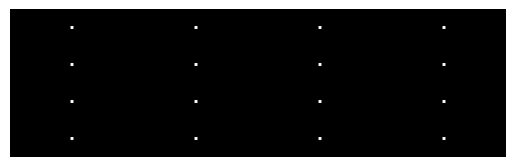

In [12]:
import numpy as np
from matplotlib import pyplot as plt

H, W = 200, 672
side = 5

img = np.zeros(shape=(H, W), dtype=np.uint8)

# Subdivide image into 4x4 grid, and fill each cell with a square with side length `side`
for i in range(4):
    for j in range(4):
        center_x = int((j + 0.5) * W / 4)
        center_y = int((i + 0.5) * H / 4)
        top_left_x = max(center_x - side // 2, 0)
        top_left_y = max(center_y - side // 2, 0)
        bottom_right_x = min(center_x + side // 2, W)
        bottom_right_y = min(center_y + side // 2, H)
        img[top_left_y:bottom_right_y, top_left_x:bottom_right_x] = 255

# Visualize
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Create an image with a single point

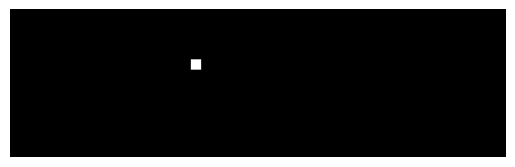

In [20]:
import numpy as np
from matplotlib import pyplot as plt

H, W = 200, 672
side = 15

img = np.zeros(shape=(H, W), dtype=np.uint8)

# Subdivide image into 4x4 grid, and index (1, 1) with a single white dot
i, j = 1, 1
center_x = int((j + 0.5) * W / 4)
center_y = int((i + 0.5) * H / 4)
top_left_x = max(center_x - side // 2, 0)
top_left_y = max(center_y - side // 2, 0)
bottom_right_x = min(center_x + side // 2, W)
bottom_right_y = min(center_y + side // 2, H)
img[top_left_y:bottom_right_y, top_left_x:bottom_right_x] = 255

# Visualize
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Or load one in

In [ ]:
import cv2

# Load in a image
img = cv2.imread('../Optical-Learning/mambo.jpeg', cv2.IMREAD_GRAYSCALE)


## Create the mask and save it

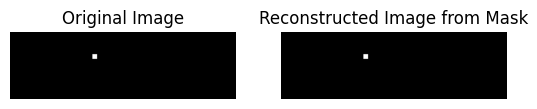

In [21]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Load in the custom checkerboard mask
mask = np.load('source/Assets/custom_checkerboard_mask.npy')

def mask2img (in_mask):
    # mask has shape [10, 1, 200, 672]
    assert in_mask.shape == (10, 1, 200, 672)
    # Convert to [200, 672]
    mask_img = np.squeeze(in_mask)
    mask_img = mask_img[0, :, :]  # Take the first region

    return mask_img

def thresholdImage (in_img, threshold=0.5):
    # Threshold the image to binary values
    out_img = np.zeros_like(in_img)
    out_img[in_img >= threshold] = 1.0
    out_img[in_img < threshold] = 0.0
    return out_img

def img2mask (in_img):
    # The image has shape [200, 672]
    # Resize the image to [200, 672]

    in_img = cv2.resize(in_img, (672, 200), interpolation=cv2.INTER_NEAREST)

    # cast to float32
    in_img = in_img.astype(np.float32)

    # If the image is in [0, 255], convert to [0, 1]
    if in_img.max() > 1.0:
        in_img = in_img / 255.0

    # Threshold the image to binary values
    in_img = thresholdImage(in_img, threshold=0.5)

    # Create the negative image
    neg_img = 1 - in_img

    # the output mask has shape [10, 1, 200, 672]
    # where the first region is in_img and 
    # the rest are neg_img
    out_mask = np.zeros((10, 1, 200, 672), dtype=np.float32)
    out_mask[0, 0, :, :] = in_img
    for i in range(1, 10):
        out_mask[i, 0, :, :] = neg_img

    return out_mask

# Convert to mask
mask = img2mask(img)

# Convert back to image
reconstructed_img = mask2img(mask)

# Display the original and reconstructed images
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Reconstructed Image from Mask')
plt.imshow(reconstructed_img, cmap='gray')
plt.axis('off')
plt.show()


In [22]:
# Save the mask
np.save('source/Assets/custom_mask_single_large.npy', mask)